In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score,confusion_matrix,classification_report,roc_curve,roc_auc_score)

In [2]:
df = pd.read_csv("loan_data.csv")
df.head(20)

,person_age,person_gender,person_education,person_income,person_emp_exp,person_home_ownership,loan_amnt,loan_intent,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,previous_loan_defaults_on_file,loan_status
0,22.0,female,Master,71948.0,0,RENT,35000.0,PERSONAL,16.02,0.49,3.0,561,No,1
1,21.0,female,High School,12282.0,0,OWN,1000.0,EDUCATION,11.14,0.08,2.0,504,Yes,0
2,25.0,female,High School,12438.0,3,MORTGAGE,5500.0,MEDICAL,12.87,0.44,3.0,635,No,1
3,23.0,female,Bachelor,79753.0,0,RENT,35000.0,MEDICAL,15.23,0.44,2.0,675,No,1
4,24.0,male,Master,66135.0,1,RENT,35000.0,MEDICAL,14.27,0.53,4.0,586,No,1
5,21.0,female,High School,12951.0,0,OWN,2500.0,VENTURE,7.14,0.19,2.0,532,No,1
6,26.0,female,Bachelor,93471.0,1,RENT,35000.0,EDUCATION,12.42,0.37,3.0,701,No,1
7,24.0,female,High School,95550.0,5,RENT,35000.0,MEDICAL,11.11,0.37,4.0,585,No,1
8,24.0,female,Associate,100684.0,3,RENT,35000.0,PERSONAL,8.90,0.35,2.0,544,No,1
9,21.0,female,High School,12739.0,0,OWN,1600.0,VENTURE,14.74,0.13,3.0,640,No,1


In [3]:
df.shape
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45000 entries, 0 to 44999
Data columns (total 14 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   person_age                      45000 non-null  float64
 1   person_gender                   45000 non-null  object 
 2   person_education                45000 non-null  object 
 3   person_income                   45000 non-null  float64
 4   person_emp_exp                  45000 non-null  int64  
 5   person_home_ownership           45000 non-null  object 
 6   loan_amnt                       45000 non-null  float64
 7   loan_intent                     45000 non-null  object 
 8   loan_int_rate                   45000 non-null  float64
 9   loan_percent_income             45000 non-null  float64
 10  cb_person_cred_hist_length      45000 non-null  float64
 11  credit_score                    45000 non-null  int64  
 12  previous_loan_defaults_on_file  

,person_age,person_income,person_emp_exp,loan_amnt,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,loan_status
count,45000.000000,4.500000e+04,45000.000000,45000.000000,45000.000000,45000.000000,45000.000000,45000.000000,45000.000000
mean,27.764178,8.031905e+04,5.410333,9583.157556,11.006606,0.139725,5.867489,632.608756,0.222222
std,6.045108,8.042250e+04,6.063532,6314.886691,2.978808,0.087212,3.879702,50.435865,0.415744
min,20.000000,8.000000e+03,0.000000,500.000000,5.420000,0.000000,2.000000,390.000000,0.000000
25%,24.000000,4.720400e+04,1.000000,5000.000000,8.590000,0.070000,3.000000,601.000000,0.000000
50%,26.000000,6.704800e+04,4.000000,8000.000000,11.010000,0.120000,4.000000,640.000000,0.000000
75%,30.000000,9.578925e+04,8.000000,12237.250000,12.990000,0.190000,8.000000,670.000000,0.000000
max,144.000000,7.200766e+06,125.000000,35000.000000,20.000000,0.660000,30.000000,850.000000,1.000000


In [4]:
df.isnull().sum()

person_age                        0
person_gender                     0
person_education                  0
person_income                     0
person_emp_exp                    0
person_home_ownership             0
loan_amnt                         0
loan_intent                       0
loan_int_rate                     0
loan_percent_income               0
cb_person_cred_hist_length        0
credit_score                      0
previous_loan_defaults_on_file    0
loan_status                       0
dtype: int64

In [5]:
df.duplicated().sum()
df.drop_duplicates(inplace=True)

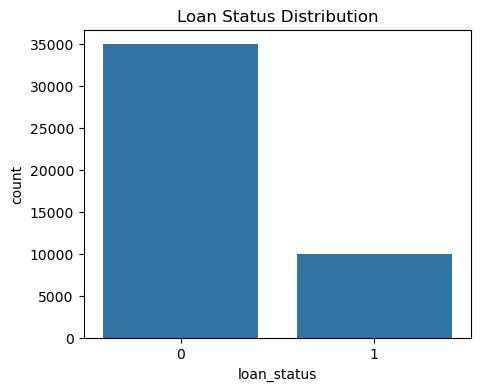

In [6]:
plt.figure(figsize=(5,4))
sns.countplot(x='loan_status', data=df)
plt.title("Loan Status Distribution")
plt.show()

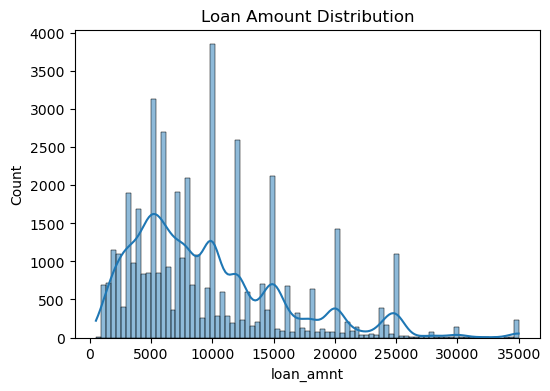

In [7]:
plt.figure(figsize=(6,4))
sns.histplot(df['loan_amnt'], kde=True)
plt.title("Loan Amount Distribution")
plt.show()

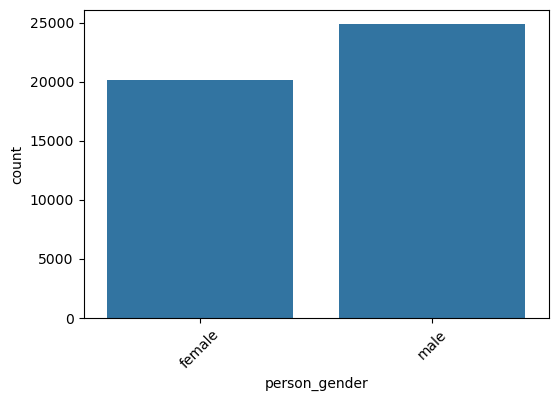

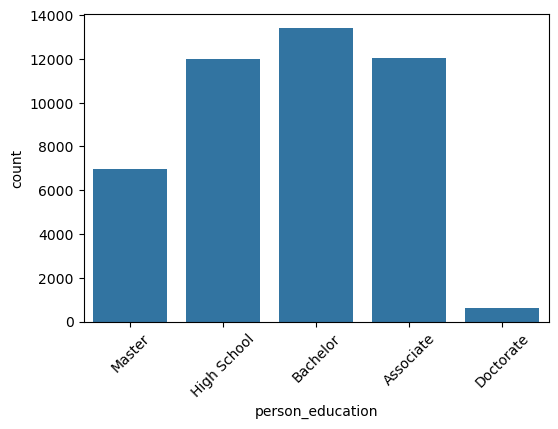

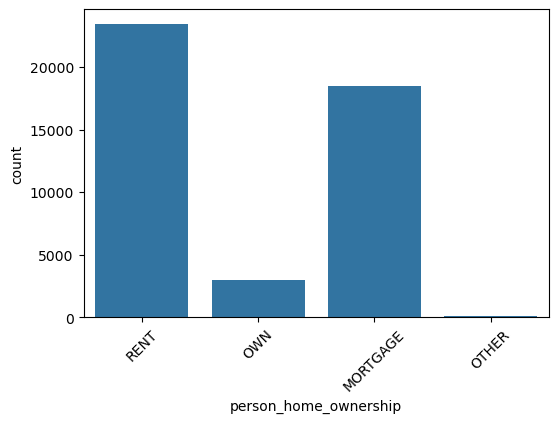

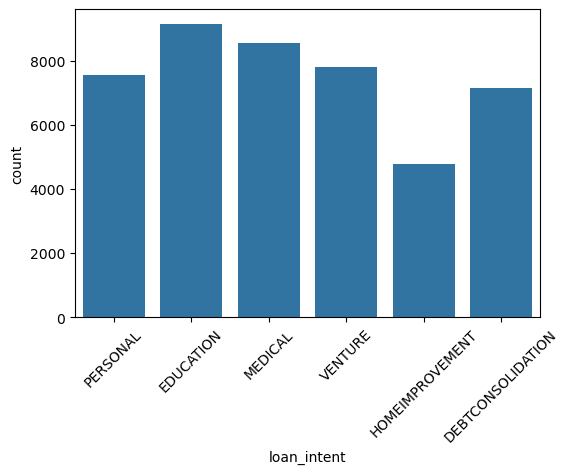

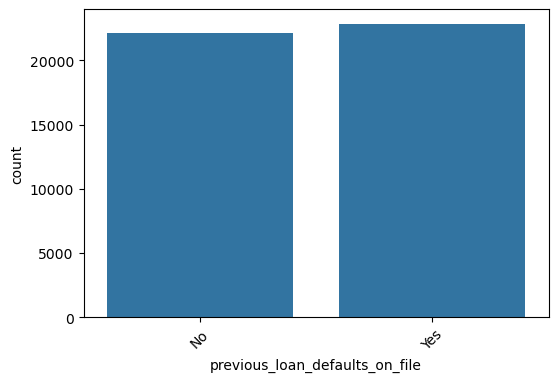

In [8]:
describe_data = df.select_dtypes(include='object').columns
for col in describe_data:
    plt.figure(figsize=(6,4))
    sns.countplot(x=col,data=df)
    plt.xticks(rotation=45)
    plt.show()

In [9]:
df_numeric = df.select_dtypes(include=['int64', 'float64'])
df_numeric.head()

,person_age,person_income,person_emp_exp,loan_amnt,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,loan_status
0,22.0,71948.0,0,35000.0,16.02,0.49,3.0,561,1
1,21.0,12282.0,0,1000.0,11.14,0.08,2.0,504,0
2,25.0,12438.0,3,5500.0,12.87,0.44,3.0,635,1
3,23.0,79753.0,0,35000.0,15.23,0.44,2.0,675,1
4,24.0,66135.0,1,35000.0,14.27,0.53,4.0,586,1


In [10]:
X = df_numeric.drop('loan_status', axis=1)
y = df_numeric['loan_status']
print(X)

       person_age  person_income  person_emp_exp  loan_amnt  loan_int_rate  \
0            22.0        71948.0               0    35000.0          16.02   
1            21.0        12282.0               0     1000.0          11.14   
2            25.0        12438.0               3     5500.0          12.87   
3            23.0        79753.0               0    35000.0          15.23   
4            24.0        66135.0               1    35000.0          14.27   
...           ...            ...             ...        ...            ...   
44995        27.0        47971.0               6    15000.0          15.66   
44996        37.0        65800.0              17     9000.0          14.07   
44997        33.0        56942.0               7     2771.0          10.02   
44998        29.0        33164.0               4    12000.0          13.23   
44999        24.0        51609.0               1     6665.0          17.05   

       loan_percent_income  cb_person_cred_hist_length  credit_

In [11]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


In [12]:
X_train,X_test,y_train,y_test=train_test_split( X_scaled, y, test_size=0.2, random_state=42,stratify=y)

In [13]:
output = LogisticRegression(max_iter=1000)
output.fit(X_train,y_train)

LogisticRegression(max_iter=1000)

In [14]:
y_pred = output.predict(X_test)

In [15]:
prob = output.predict_proba(X_test)
results = pd.DataFrame({ "Actual": y_test.values, "Predicted": y_pred, "Probability of Class 0": prob[:,0], "Probability of Class 1": prob[:,1]})
print(results.head(10))

   Actual  Predicted  Probability of Class 0  Probability of Class 1
0       0          0                0.976904                0.023096
1       0          0                0.785966                0.214034
2       0          0                0.966703                0.033297
3       0          0                0.976951                0.023049
4       1          0                0.780406                0.219594
5       1          0                0.892034                0.107966
6       0          0                0.950651                0.049349
7       0          0                0.965918                0.034082
8       0          0                0.912856                0.087144
9       0          0                0.961878                0.038122


In [16]:
accuracy = accuracy_score(y_test,y_pred)
print("Accuracy:",accuracy)

Accuracy: 0.8266666666666667


In [17]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.85      0.95      0.89      7000
           1       0.69      0.40      0.51      2000

    accuracy                           0.83      9000
   macro avg       0.77      0.68      0.70      9000
weighted avg       0.81      0.83      0.81      9000



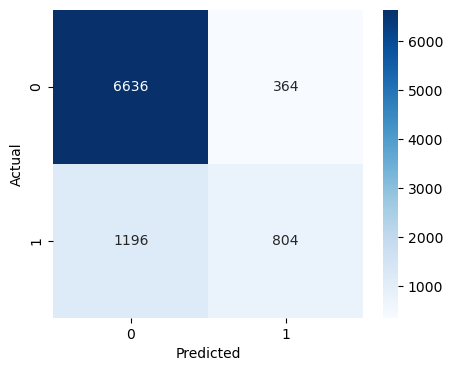

In [18]:
cm = confusion_matrix(y_test,y_pred)
plt.figure(figsize=(5,4))
sns.heatmap(cm,annot=True,fmt='d',cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [19]:
importance = pd.DataFrame({ "Feature": X.columns, "Coefficient": output.coef_[0]})
print(importance)

                      Feature  Coefficient
0                  person_age     0.101105
1               person_income     0.019964
2              person_emp_exp    -0.062718
3                   loan_amnt    -0.661744
4               loan_int_rate     1.001610
5         loan_percent_income     1.330686
6  cb_person_cred_hist_length    -0.029527
7                credit_score    -0.006616


In [20]:
results.to_csv("loan_prediction_results.csv", index=False)

In [21]:
new_applicant = [[
    35,      # person_age
    70000,   # person_income
    8,       # person_emp_exp
    15000,   # loan_amnt
    9.5,     # loan_int_rate
    0.21,    # loan_percent_income
    10,      # cb_person_cred_hist_length
    740       # credit_score 
]]
new_applicant = scaler.transform(new_applicant)
prediction = output.predict(new_applicant)
print(prediction)


[0]


C:\Users\indra\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [22]:
import joblib
joblib.dump(output, "loan_model3.pkl")
joblib.dump(scaler, "scaler3.pkl")

['scaler3.pkl']